# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [2]:
%pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/39.1 MB 117.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 91.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [rioxarray]/4 [xarray]o]
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import the four packages here.
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path


## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [4]:
boundary_path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"

# Read the boundary.
# Print its CRS and shape.
# Dissolve it to one row.
maine_boundary = gpd.read_file(boundary_path)

print(maine_boundary.shape)
print(maine_boundary.crs)

(6204, 10)
EPSG:4326


In [5]:
maine_boundary = maine_boundary.dissolve()
maine_boundary.shape

(1, 10)

## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [6]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [7]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims)
print("Shape:", bio1.shape)
print("Data type:", bio1.dtype)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32


In [8]:
print("CRS:", bio1.rio.crs)
print("Resolution:", bio1.rio.resolution())
print("Bounds:", bio1.rio.bounds())
print("NoData:", bio1.rio.nodata)

CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


In [ ]:
Dimensions: 1 band means the data is showing one variable, in this case, it's the mean annual temperature. Y is latitude and x is longitude. 
Shape: Raster has 4,320 rows and 8640 columns. 
Data type: Each cell is stored as a 32 bit decimal number. 
CRS: EPSG:4326 is the code for the coordinate system. 
Resolution: The size of each cell in degrees.
Bounds: The edge of each raster as west, south, east or north. 
NoData: Value that marks no data cells. 

## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [9]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [10]:
# Compare global and clipped metadata here.
print("Global shape:", bio1.shape)
print("Maine shape:", bio1_maine.shape)
print("Maine bounds:", bio1_maine.rio.bounds())
print("Maine resolution:", bio1_maine.rio.resolution())

Global shape: (1, 4320, 8640)
Maine shape: (109, 101)
Maine bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
Maine resolution: (0.04166666666666671, -0.041666666666666664)


**Your comparison:** The shape changed. It went from 1, 4320, 8640 to 109,101. 
The bounds shrank, went from (-180, -90, 180, 90) to (-71.125, 42.958, -66.917, 47.5).
The CRS stayed the same, clipping didn't reproject the raster. 
Resolution is still 1/24 of a degree (2.5 arcminutes) per cell.

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

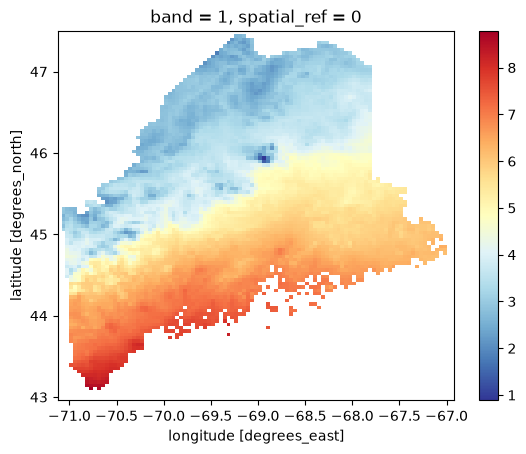

In [11]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="RdYlBu_r")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** Bio6, min temp of the coldest month. Cold sensitive species like amphibians need winters that aren't too severe, this variable will give a range of severe temperatures in the winter. 

**Variable 2 and justification:** Bio12, annual precipitation. This variable is useful because amphibians have thin skin and need moisture in order to prevent drying out. 

**Variable 3 and justification:** Bi018, precipitation of the warmest quarter. Amphibians need pools to breed so good to identify when there will be a lot of rain, especially in the summer when it is dry. 

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [12]:
# Open your first additional raster.
# Inspect its metadata.
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio6_path = bioclim_path / "wc2.1_2.5m_bio_6.tif"

bio6 = rxr.open_rasterio(
    bio6_path,
    masked=True,
)

bio6

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  26.450000762939
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -72.503997802734
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

In [13]:
print("CRS:", bio6.rio.crs)
print("Shape:", bio6.shape)
print("Resolution:", bio6.rio.resolution())
print("Bounds:", bio6.rio.bounds())

CRS: EPSG:4326
Shape: (1, 4320, 8640)
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [14]:
# Compare the first additional raster with bio1.
bio6.rio.crs == bio1.rio.crs
bio6.shape == bio1.shape
bio6.rio.resolution() == bio1.rio.resolution()
bio6.rio.bounds() == bio1.rio.bounds()

True

## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

In [15]:
# Clip, squeeze, and plot the first additional raster.
bio6_maine = bio6.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio6_maine = bio6_maine.squeeze()

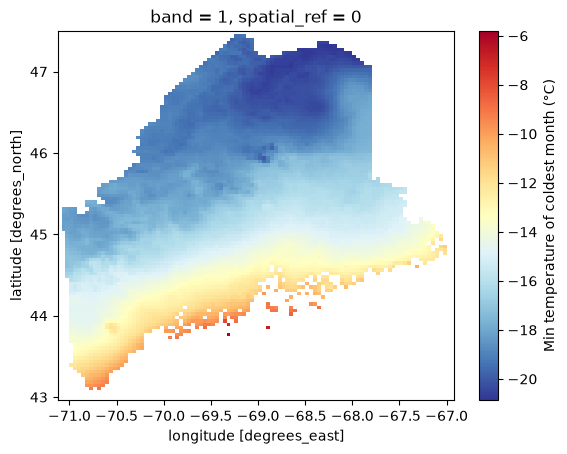

In [16]:
bio6_maine.plot(
    cmap="RdYlBu_r",
    cbar_kwargs={"label": "Min temperature of coldest month (°C)"},
)

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

In [17]:
# Complete the workflow for the second additional raster.
bio12_path = bioclim_path / "wc2.1_2.5m_bio_12.tif"
bio12_path.exists()

True

In [18]:
bio12 = rxr.open_rasterio(bio12_path, masked=True)
bio12

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  11246
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

In [19]:
bio12.rio.crs == bio1.rio.crs
bio12.shape == bio1.shape
bio12.rio.resolution() == bio1.rio.resolution()
bio12.rio.bounds() == bio1.rio.bounds()

True

In [20]:
bio12_maine = bio12.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

In [21]:
bio12_maine = bio12_maine.squeeze()
bio12_maine.shape

(109, 101)

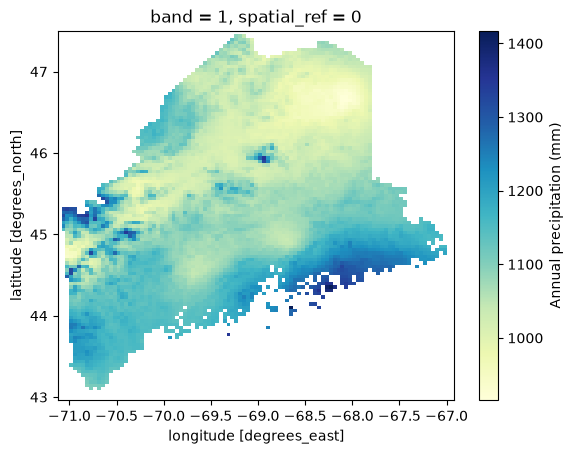

In [22]:
bio12_maine.plot(
    cmap="YlGnBu",
    cbar_kwargs={"label": "Annual precipitation (mm)"},
)

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

In [23]:
# Complete the workflow for the third additional raster.
bio18_path = bioclim_path / "wc2.1_2.5m_bio_18.tif"
bio18_path.exists()

True

In [24]:
bio18 = rxr.open_rasterio(bio18_path, masked=True)
bio18

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  5608
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

In [25]:
bio18.rio.crs == bio1.rio.crs
bio18.shape == bio1.shape
bio18.rio.resolution() == bio1.rio.resolution()
bio18.rio.bounds() == bio1.rio.bounds()

True

In [26]:
bio18_maine = bio18.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

In [27]:
bio18_maine = bio18_maine.squeeze()
bio18_maine.shape

(109, 101)

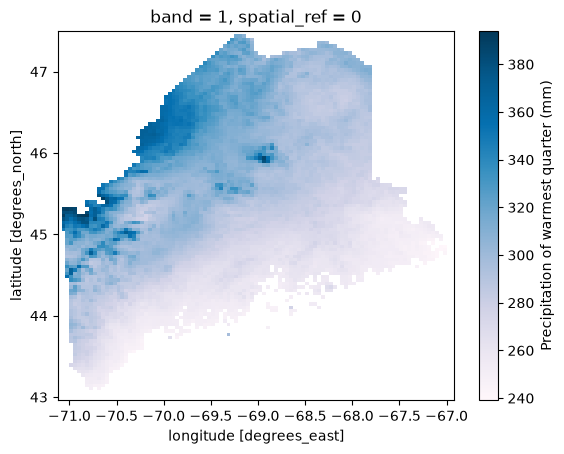

In [28]:
bio18_maine.plot(
    cmap="PuBu",
    cbar_kwargs={"label": "Precipitation of warmest quarter (mm)"},
)

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [29]:
amphibians = pd.read_csv(
    "Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

In [30]:
amphibians = amphibians[["gbifID", "species", "decimalLongitude", "decimalLatitude", "year"]]
amphibians.head()

,gbifID,species,decimalLongitude,decimalLatitude,year
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026.0
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,2026.0
3,6520721493,Lithobates palustris,-68.636788,44.860466,2022.0
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026.0


## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [31]:
# Convert both coordinate columns with pd.to_numeric().
# Drop rows missing species, longitude, or latitude.
amphibians["decimalLongitude"] = pd.to_numeric(amphibians["decimalLongitude"], errors="coerce")
amphibians["decimalLatitude"] = pd.to_numeric(amphibians["decimalLatitude"], errors="coerce")

In [32]:
amphibians = amphibians.dropna(subset=["species", "decimalLongitude", "decimalLatitude"]).copy()
amphibians.shape

(25586, 5)

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [33]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1:** Lithobates catesbeianus

**Species 2:** Pseudacris crucifer

**Species 3:** Ambystoma maculatum

In [34]:
selected_species = [
    "Lithobates catesbeianus",
    "Pseudacris crucifer",
    "Ambystoma maculatum",
]

# Filter the occurrence table with .isin(selected_species).
amphibians_selected = amphibians[amphibians["species"].isin(selected_species)].copy()
amphibians_selected.shape

(7614, 5)

In [35]:
amphibians_selected["species"].value_counts()

species
Pseudacris crucifer        2801
Ambystoma maculatum        2511
Lithobates catesbeianus    2302
Name: count, dtype: int64

## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [36]:
# Create selected_amphibians_gdf here.
selected_amphibians_gdf = gpd.GeoDataFrame(
    amphibians_selected,
    geometry=gpd.points_from_xy(
        amphibians_selected["decimalLongitude"],
        amphibians_selected["decimalLatitude"],
    ),
    crs="EPSG:4326",
)

selected_amphibians_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026.0,POINT (-68.66028 44.90255)
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0,POINT (-68.70405 44.78842)
14,6520623627,Lithobates catesbeianus,-68.248452,44.295458,2023.0,POINT (-68.24845 44.29546)
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0,POINT (-70.85036 44.27281)
18,6520605074,Lithobates catesbeianus,-68.490129,46.756350,2026.0,POINT (-68.49013 46.75635)


In [37]:
selected_amphibians_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [38]:
# Print both coordinate systems.
print("Occurrence CRS:", selected_amphibians_gdf.crs)
print("Raster CRS:", bio1_maine.rio.crs)

Occurrence CRS: EPSG:4326
Raster CRS: EPSG:4326


**Your explanation:** The points and raster are in the same coordinate system so can be compared directly, they are both in EPSG:4326

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [39]:
# Create point_x from point longitude.
# Create point_y from point latitude.
point_x = xr.DataArray(selected_amphibians_gdf.geometry.x.values, dims="record")

In [40]:
point_y = xr.DataArray(selected_amphibians_gdf.geometry.y.values, dims="record")

In [41]:
print(point_x.dims, point_x.shape)
print(point_y.dims, point_y.shape)
len(selected_amphibians_gdf)

('record',) (7614,)
('record',) (7614,)


7614

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [42]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.

In [43]:
selected_amphibians_gdf["bio1_annual_mean_temp_c"] = bio1_values.values
selected_amphibians_gdf[["species", "bio1_annual_mean_temp_c"]].head()

,species,bio1_annual_mean_temp_c
0,Lithobates catesbeianus,6.609500
6,Pseudacris crucifer,6.634333
14,Lithobates catesbeianus,6.842187
15,Pseudacris crucifer,6.033667
18,Lithobates catesbeianus,3.338000


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [44]:
# Count missing extracted BIO1 values.
missing_bio1 = selected_amphibians_gdf["bio1_annual_mean_temp_c"].isna().sum()
missing_bio1

np.int64(454)

**Your explanation:** The raster is coarser than the coordinates so a point can still land in a cell that doesn't have any climate value.

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [45]:
# Extract values from the first additional clipped raster.
# Add the values to selected_amphibians_gdf.
bio6_values = bio6_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
selected_amphibians_gdf["bio6_min_temp_coldest_month_c"] = bio6_values.values

In [46]:
# Extract values from the second additional clipped raster.
# Add the values to selected_amphibians_gdf.
bio12_values = bio12_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
selected_amphibians_gdf["bio12_annual_precip_mm"] = bio12_values.values

In [47]:
# Extract values from the third additional clipped raster.
# Add the values to selected_amphibians_gdf.
bio18_values = bio18_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)
selected_amphibians_gdf["bio18_warmest_quarter_precip_mm"] = bio18_values.values

## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [48]:
# Create and display occurrence_environment.
occurrence_environment = pd.DataFrame(selected_amphibians_gdf.drop(columns="geometry"))
occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_annual_mean_temp_c,bio6_min_temp_coldest_month_c,bio12_annual_precip_mm,bio18_warmest_quarter_precip_mm
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026.0,6.609500,-13.808000,1044.0,266.0
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0,6.634333,-13.624001,1091.0,261.0
14,6520623627,Lithobates catesbeianus,-68.248452,44.295458,2023.0,6.842187,-11.387500,1381.0,263.0
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0,6.033667,-14.884000,1126.0,295.0
18,6520605074,Lithobates catesbeianus,-68.490129,46.756350,2026.0,3.338000,-20.275999,964.0,289.0


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [49]:
# Calculate species-level summaries here.
climate_cols = [
    "bio1_annual_mean_temp_c",
    "bio6_min_temp_coldest_month_c",
    "bio12_annual_precip_mm",
    "bio18_warmest_quarter_precip_mm",
]

species_summary = occurrence_environment.groupby("species")[climate_cols].agg(["mean", "std"])
species_summary["n_records"] = occurrence_environment.groupby("species").size()
species_summary.round(2)

bio1_annual_mean_temp_c        \
                                           mean   std   
species                                                 
Ambystoma maculatum                        6.16  1.46   
Lithobates catesbeianus                    6.64  0.99   
Pseudacris crucifer                        6.55  1.24   

                        bio6_min_temp_coldest_month_c        \
                                                 mean   std   
species                                                       
Ambystoma maculatum                            -13.93  3.07   
Lithobates catesbeianus                        -12.76  2.12   
Pseudacris crucifer                            -13.33  2.59   

                        bio12_annual_precip_mm          \
                                          mean     std   
species                                                  
Ambystoma maculatum                    1144.52  110.66   
Lithobates catesbeianus                1230.99  133.93   
Pseudacris crucifer                    1138.15   81.64   

                        bio18_warmest_quarter_precip_mm        n_records  
                                                   mean    std            
species                                                                   
Ambystoma maculatum                              270.18  19.02      2511  
Lithobates catesbeianus                          266.25  15.66      2302  
Pseudacris crucifer                              266.87  17.37      2801

## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [50]:
# Select the four predictor columns and calculate .corr().
climate_cols = [
    "bio1_annual_mean_temp_c",
    "bio6_min_temp_coldest_month_c",
    "bio12_annual_precip_mm",
    "bio18_warmest_quarter_precip_mm",
]

corr_table = occurrence_environment[climate_cols].corr()
corr_table.round(2)

,bio1_annual_mean_temp_c,bio6_min_temp_coldest_month_c,bio12_annual_precip_mm,bio18_warmest_quarter_precip_mm
bio1_annual_mean_temp_c,1.00,0.96,0.46,-0.91
bio6_min_temp_coldest_month_c,0.96,1.00,0.61,-0.91
bio12_annual_precip_mm,0.46,0.61,1.00,-0.42
bio18_warmest_quarter_precip_mm,-0.91,-0.91,-0.42,1.00


In [52]:
import numpy as np

In [53]:
corr_pairs = corr_table.where(~np.tril(np.ones(corr_table.shape, dtype=bool)))
corr_pairs.stack().sort_values(key=abs, ascending=False).round(2)

bio1_annual_mean_temp_c          bio6_min_temp_coldest_month_c      0.96
                                 bio18_warmest_quarter_precip_mm   -0.91
bio6_min_temp_coldest_month_c    bio18_warmest_quarter_precip_mm   -0.91
                                 bio12_annual_precip_mm             0.61
bio1_annual_mean_temp_c          bio12_annual_precip_mm             0.46
bio12_annual_precip_mm           bio18_warmest_quarter_precip_mm   -0.42
bio1_annual_mean_temp_c          bio1_annual_mean_temp_c             NaN
bio6_min_temp_coldest_month_c    bio1_annual_mean_temp_c             NaN
                                 bio6_min_temp_coldest_month_c       NaN
bio12_annual_precip_mm           bio1_annual_mean_temp_c             NaN
                                 bio6_min_temp_coldest_month_c       NaN
                                 bio12_annual_precip_mm              NaN
bio18_warmest_quarter_precip_mm  bio1_annual_mean_temp_c             NaN
                                 bio6_min_temp_cold

**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning.
Bio1 and Bio6 have a strong relationship
Bio1 and Bio18 have a strong relationship
Bio6 and Bio18 have a strong relationship
Bio1, Bio6, and Bio18 contain similar information and predict one gradient.
I would keep Bio6 and drop Bio1 and Bio18 because Bio6 has the clearest measurement for amphibians. Bio1 is general and Bio18 is redundant.

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [54]:
# Save occurrence_environment with .to_csv().
occurrence_environment.to_csv("Assignment05_environmental_values.csv", index=False)

In [55]:
Path("Assignment05_environmental_values.csv").exists()

True

In [56]:
pd.read_csv("Assignment05_environmental_values.csv").head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_annual_mean_temp_c,bio6_min_temp_coldest_month_c,bio12_annual_precip_mm,bio18_warmest_quarter_precip_mm
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026.0,6.609500,-13.808000,1044.0,266.0
1,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026.0,6.634333,-13.624001,1091.0,261.0
2,6520623627,Lithobates catesbeianus,-68.248452,44.295458,2023.0,6.842187,-11.387500,1381.0,263.0
3,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026.0,6.033667,-14.884000,1126.0,295.0
4,6520605074,Lithobates catesbeianus,-68.490129,46.756350,2026.0,3.338000,-20.275999,964.0,289.0


## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact?
Raster tells you how finely the climate data can distinguish places. Coordinate sets how well where you know a record really is. 

2. What environmental variation is lost when all occurrences in one raster cell receive the same value?
Elevation and slope effects. Variation among records in the same cell. 

3. Which predictor has the strongest biological justification for your selected species?
Bio6, minimum temperature of the coldest month. Amphibians are ectotherms and have difficulty surviving in harsh weather so it would be useful to know where the boundary/limit range on a map is for amphibians. 

4. Which preprocessing choice is most important to document for reproducibility?
Record filtering and missing values. This will record which records that stay in the analysis and missing values records what happens to ones without climate value. 
                                                            
5. Name one additional environmental predictor you would seek for an amphibian study and explain why.
    Distance to the nearest water. Because amphibians need water and it is independent of the temperature gradient. 

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```